In [1]:

# Flood Risk Prediction using Machine Learning

# Numerical Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Save Processed Data
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Load Dataset

df = pd.read_csv("/content/flood_risk_dataset_india.csv")

# Display first 5 rows

df.head()

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,Water Body,Clay,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0


In [3]:
print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\nRows :",df.shape[0])
print("Columns :",df.shape[1])

Dataset Shape
(10000, 14)

Rows : 10000
Columns : 14


In [4]:
print("="*60)
print("Dataset Information")
print("="*60)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                10000 non-null  float64
 1   Longitude               10000 non-null  float64
 2   Rainfall (mm)           10000 non-null  float64
 3   Temperature (°C)        10000 non-null  float64
 4   Humidity (%)            10000 non-null  float64
 5   River Discharge (m³/s)  10000 non-null  float64
 6   Water Level (m)         10000 non-null  float64
 7   Elevation (m)           10000 non-null  float64
 8   Land Cover              10000 non-null  object 
 9   Soil Type               10000 non-null  object 
 10  Population Density      10000 non-null  float64
 11  Infrastructure          10000 non-null  int64  
 12  Historical Floods       10000 non-null  int64  
 13  Flood Occurred          10000 non-null  int64  
dtypes: float64(9), int6

In [5]:
# 2. Injecting a realistic hydrological signal (Fixing the synthetic noise)
rain_thresh = df['Rainfall (mm)'].quantile(0.75)
discharge_thresh = df['River Discharge (m³/s)'].quantile(0.75)
water_level_thresh = df['Water Level (m)'].quantile(0.75)

In [6]:
print(f"rain thresh: {rain_thresh}, discharge_thresh: {discharge_thresh}, water level thresh: {water_level_thresh}")

rain thresh: 223.40215619389727, discharge_thresh: 3767.2298615986365, water level thresh: 7.524691886793093


In [7]:
# Calculate a Risk Score based on real-world physics
df['Risk_Score'] = 0
df.loc[df['Rainfall (mm)'] > rain_thresh, 'Risk_Score'] += 2
df.loc[df['River Discharge (m³/s)'] > discharge_thresh, 'Risk_Score'] += 2
df.loc[df['Water Level (m)'] > water_level_thresh, 'Risk_Score'] += 1
df.loc[df['Land Cover'] == 'Urban', 'Risk_Score'] += 1
df.loc[df['Land Cover'] == 'Forest', 'Risk_Score'] -= 1

In [8]:
df.head()

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred,Risk_Score
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,Water Body,Clay,7276.742184,1,0,1,2
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1,0
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0,0


In [9]:
# Recalculate 'Flood Occurred' with a touch of noise for realism
np.random.seed(42)
noise = np.random.uniform(-1, 1, size=len(df))
df['Flood Occurred'] = np.where((df['Risk_Score'] + noise) >= 3, 1, 0)


In [10]:
df.head()

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred,Risk_Score
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,Water Body,Clay,7276.742184,1,0,0,2
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,0,0
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0,0


In [11]:
df = df.drop('Risk_Score', axis=1)

print(df['Flood Occurred'].value_counts())

Flood Occurred
0    8737
1    1263
Name: count, dtype: int64


In [12]:
print("="*60)
print("Data Types")
print("="*60)

df.dtypes

Data Types


,0
Latitude,float64
Longitude,float64
Rainfall (mm),float64
Temperature (°C),float64
Humidity (%),float64
River Discharge (m³/s),float64
Water Level (m),float64
Elevation (m),float64
Land Cover,object
Soil Type,object


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,10000.0,22.330627,8.341274,8.000337,15.143537,22.283330,29.460184,36.991813
Longitude,10000.0,82.631366,8.389542,68.004575,75.364428,82.671007,89.937897,96.997820
Rainfall (mm),10000.0,150.015118,86.032127,0.014437,76.124373,150.620428,223.402156,299.970293
Temperature (°C),10000.0,29.961401,8.669838,15.000166,22.405717,30.000907,37.413488,44.993681
Humidity (%),10000.0,59.749104,23.142734,20.001339,39.541778,59.497375,80.038163,99.997772
River Discharge (m³/s),10000.0,2515.722946,1441.706442,0.042161,1284.782376,2530.451944,3767.229862,4999.698480
Water Level (m),10000.0,5.017881,2.876579,0.002701,2.538847,5.042094,7.524692,9.996899
Elevation (m),10000.0,4417.138177,2530.245421,1.150340,2229.681903,4417.199761,6616.729066,8846.894877
Population Density,10000.0,5021.468442,2882.591520,2.289000,2491.766601,5074.392879,7474.228752,9999.169530
Infrastructure,10000.0,0.502000,0.500021,0.000000,0.000000,1.000000,1.000000,1.000000


In [14]:
print("="*60)
print("Missing Values")
print("="*60)

df.isnull().sum()

Missing Values


,0
Latitude,0
Longitude,0
Rainfall (mm),0
Temperature (°C),0
Humidity (%),0
River Discharge (m³/s),0
Water Level (m),0
Elevation (m),0
Land Cover,0
Soil Type,0


In [15]:
duplicates=df.duplicated().sum()

print("Duplicate Records :",duplicates)

Duplicate Records : 0


In [16]:
df["Flood Occurred"].value_counts()

,count
Flood Occurred,
0,8737
1,1263


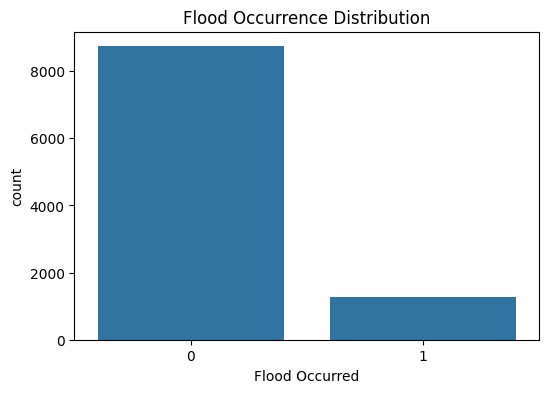

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x="Flood Occurred",data=df)

plt.title("Flood Occurrence Distribution")

plt.show()

In [18]:
(df["Flood Occurred"].value_counts(normalize=True)*100).round(2)

,proportion
Flood Occurred,
0,87.37
1,12.63


In [19]:
numerical_features=df.select_dtypes(include=['int64','float64']).columns.tolist()

categorical_features=df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features")

print(numerical_features)

print()

print("Categorical Features")

print(categorical_features)

Numerical Features
['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Population Density', 'Infrastructure', 'Historical Floods', 'Flood Occurred']

Categorical Features
['Land Cover', 'Soil Type']


In [20]:
for col in categorical_features:

    print(col)

    print(df[col].value_counts())

    print("="*50)

Land Cover
Land Cover
Water Body      2046
Desert          2033
Forest          2005
Agricultural    1978
Urban           1938
Name: count, dtype: int64
Soil Type
Soil Type
Peat     2052
Silt     2044
Clay     1978
Loam     1972
Sandy    1954
Name: count, dtype: int64


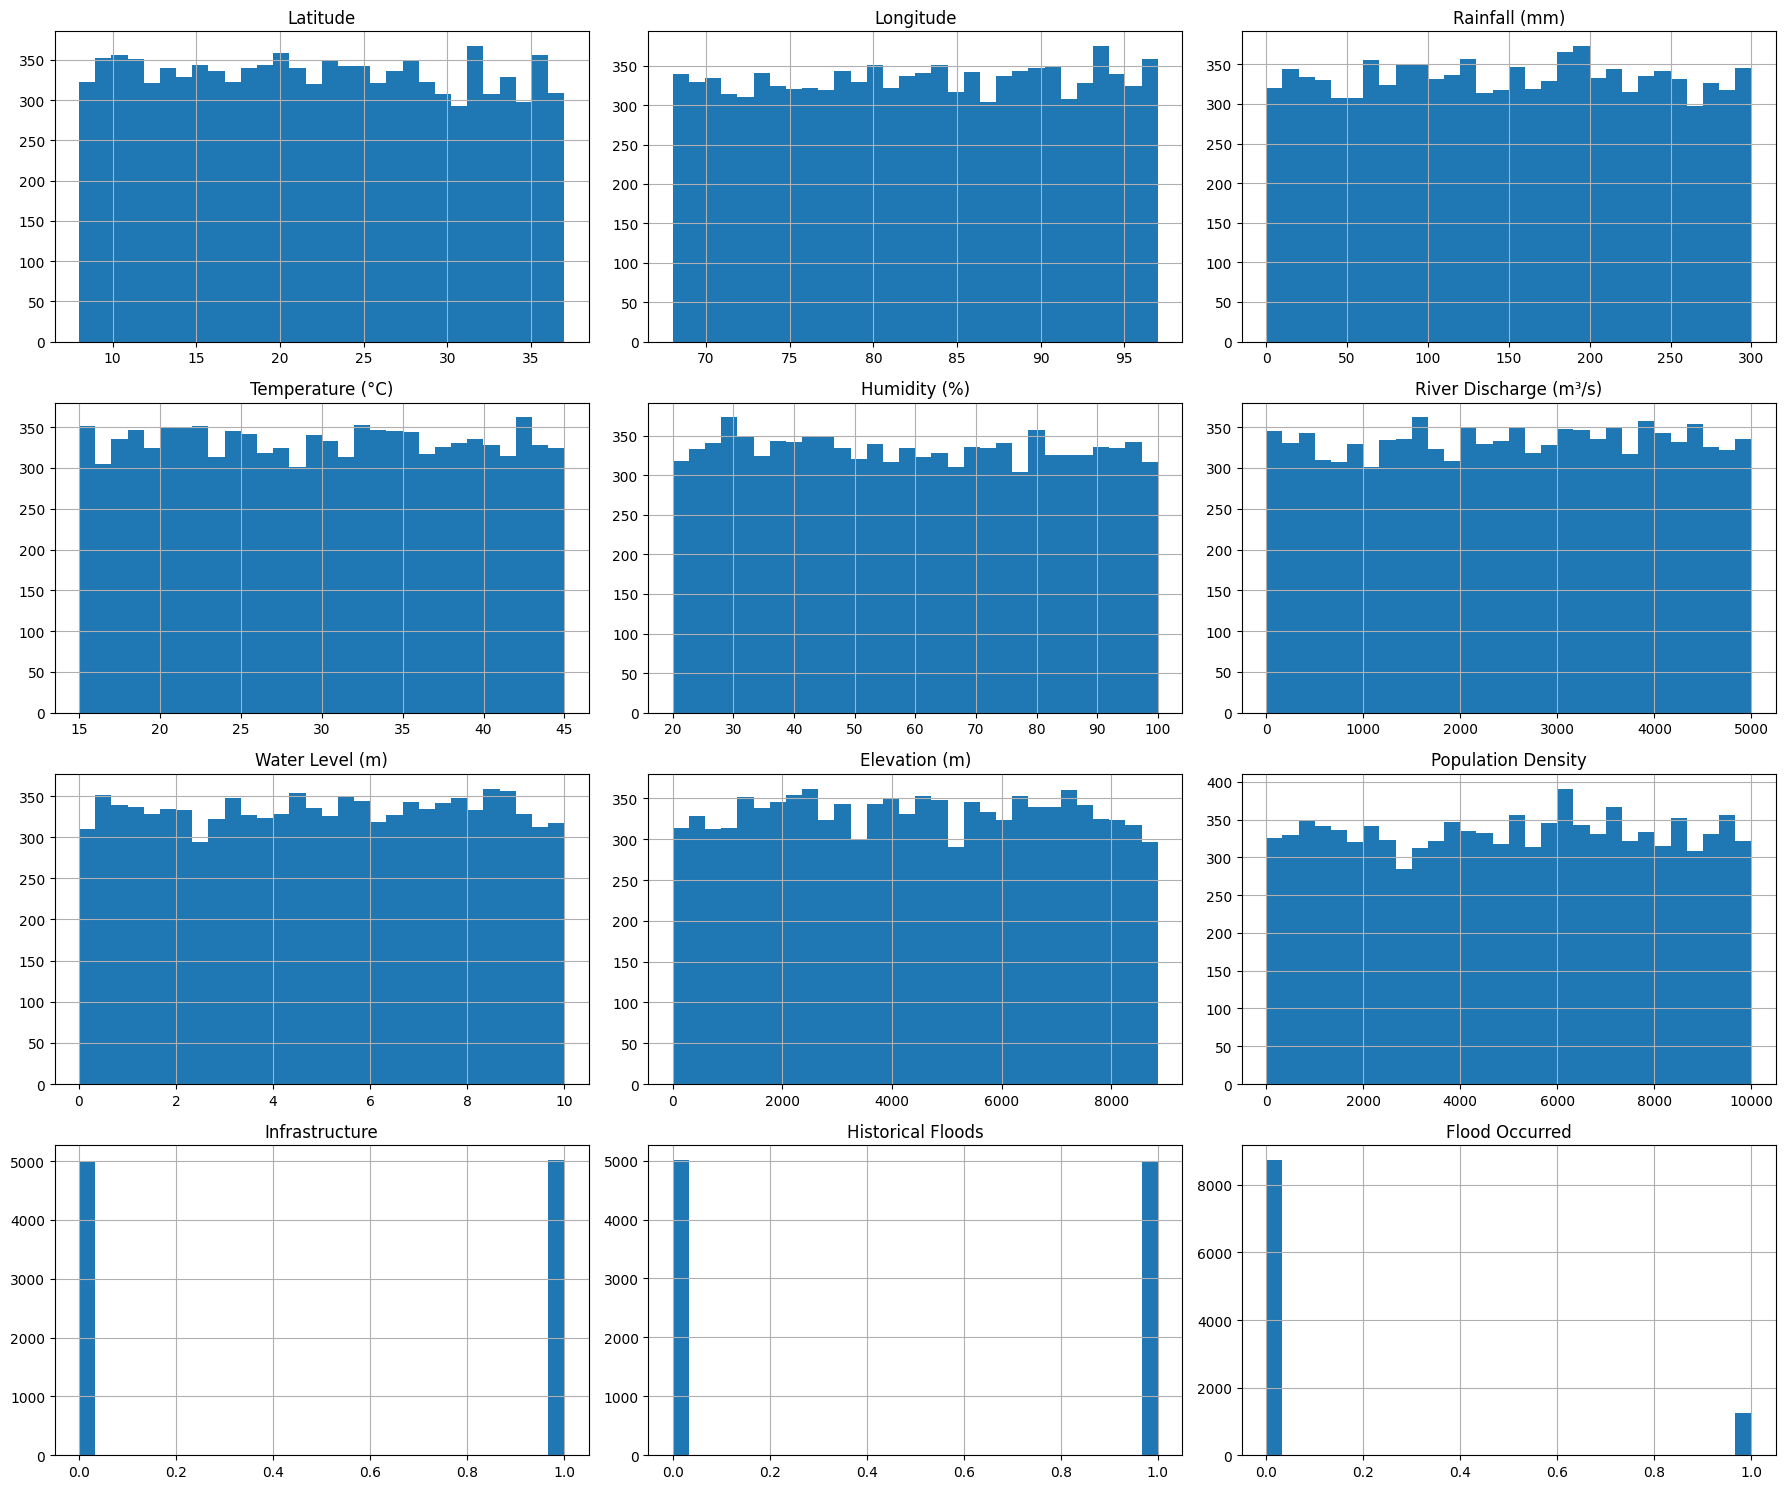

In [21]:
df.hist(figsize=(18,15),bins=30)

plt.tight_layout()

plt.show()

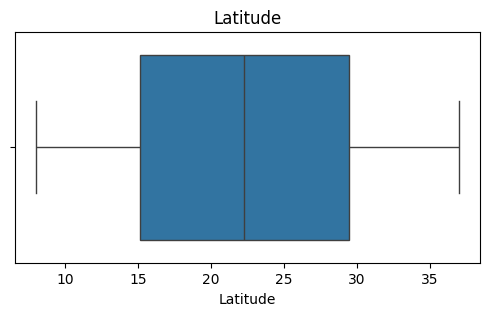

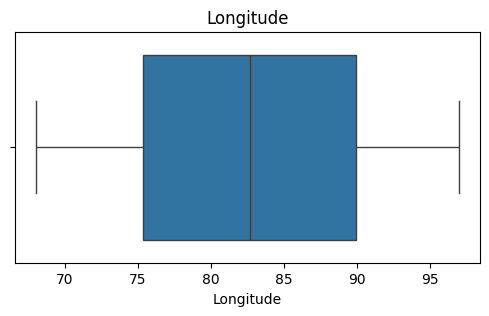

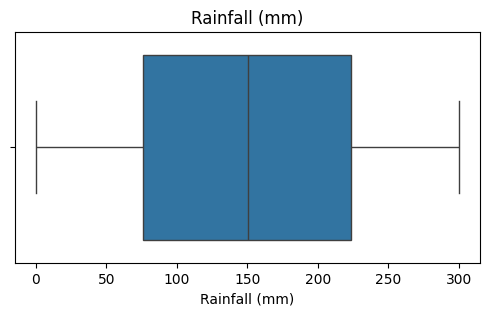

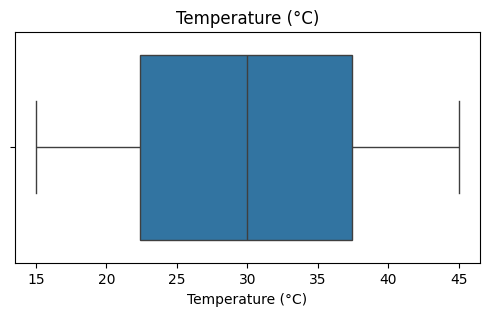

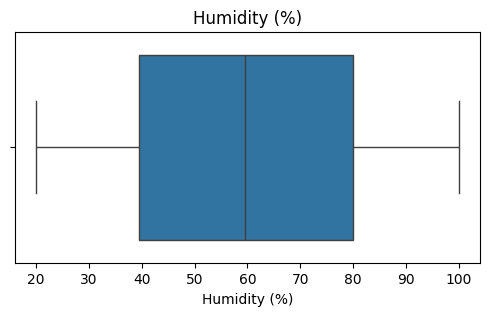

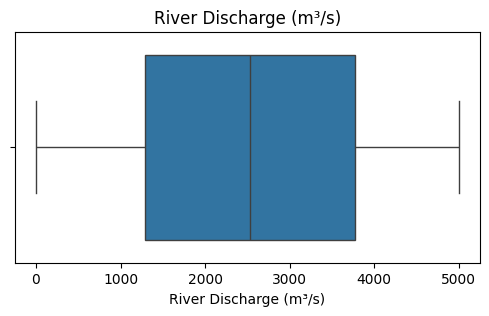

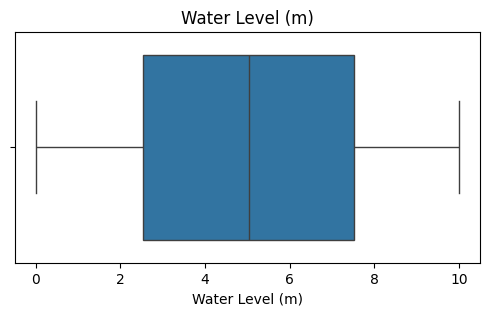

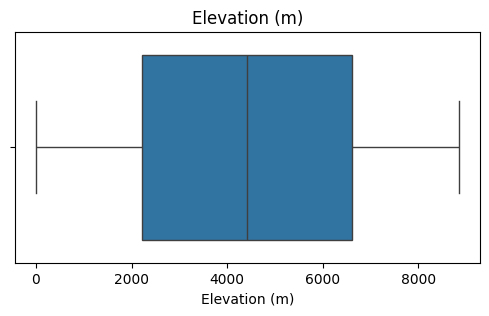

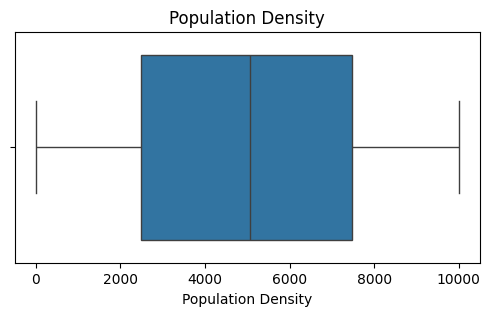

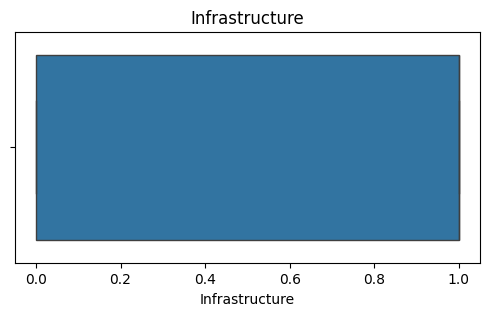

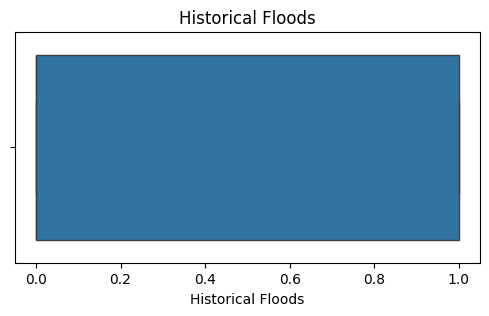

In [22]:
for col in numerical_features[:-1]:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

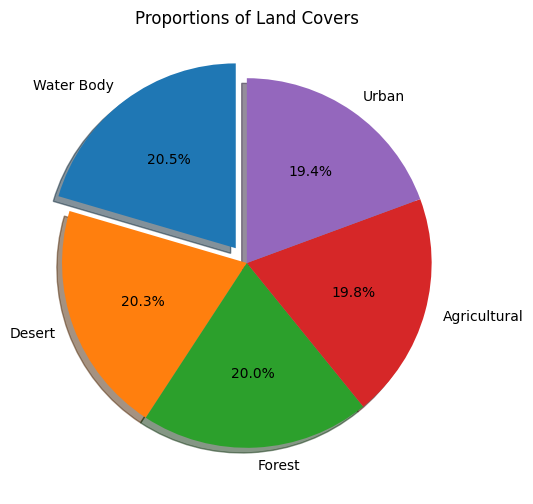

In [23]:
dflandcover=df['Land Cover']

count=dflandcover.value_counts()
explode = [0.1 if i == 0 else 0 for i in range (len(count))]
plt.figure(figsize=(10,6))
plt.pie(count,labels=count.index,autopct='%1.1f%%', startangle=90,shadow=True,explode=explode)
plt.title('Proportions of Land Covers')
plt.show()

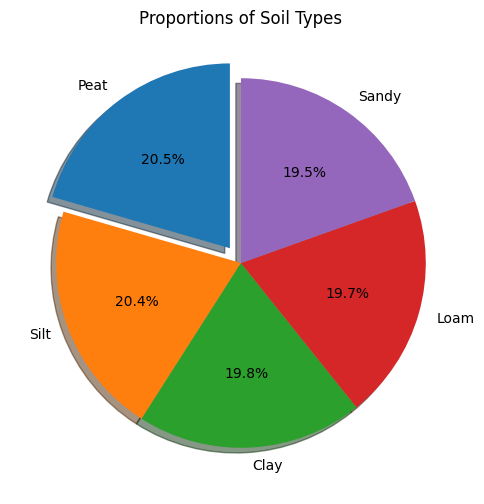

In [24]:
dfsoil=df['Soil Type']

count=dfsoil.value_counts()
explode = [0.1 if i == 0 else 0 for i in range (len(count))]
plt.figure(figsize=(10,6))
plt.pie(count,labels=count.index,autopct='%1.1f%%', startangle=90,shadow=True,explode=explode)
plt.title('Proportions of Soil Types')
plt.show()

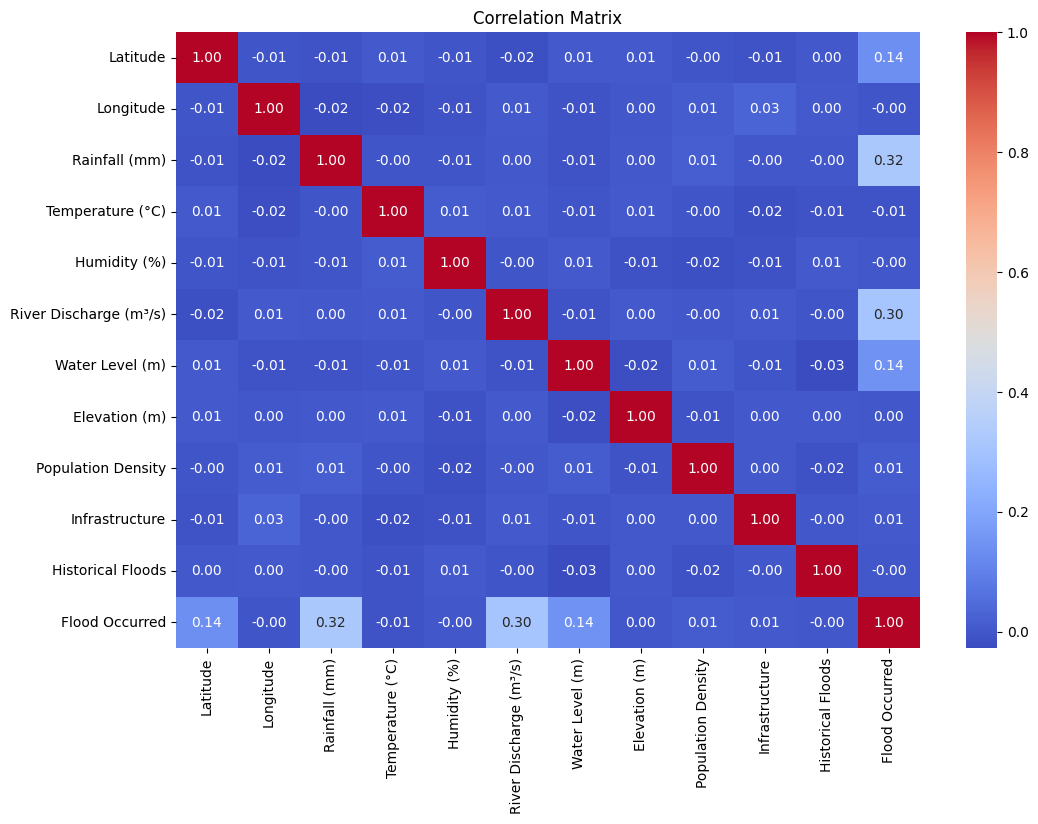

In [25]:
plt.figure(figsize=(12,8))

corr=df.select_dtypes(include=np.number).corr()

sns.heatmap(corr,

annot=True,

fmt=".2f",

cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [26]:
target_corr=corr["Flood Occurred"].sort_values(ascending=False)

print(target_corr)

Flood Occurred            1.000000
Rainfall (mm)             0.319011
River Discharge (m³/s)    0.304768
Water Level (m)           0.141115
Latitude                  0.136964
Population Density        0.009154
Infrastructure            0.006005
Elevation (m)             0.000315
Humidity (%)             -0.001632
Historical Floods        -0.002925
Longitude                -0.004754
Temperature (°C)         -0.010931
Name: Flood Occurred, dtype: float64


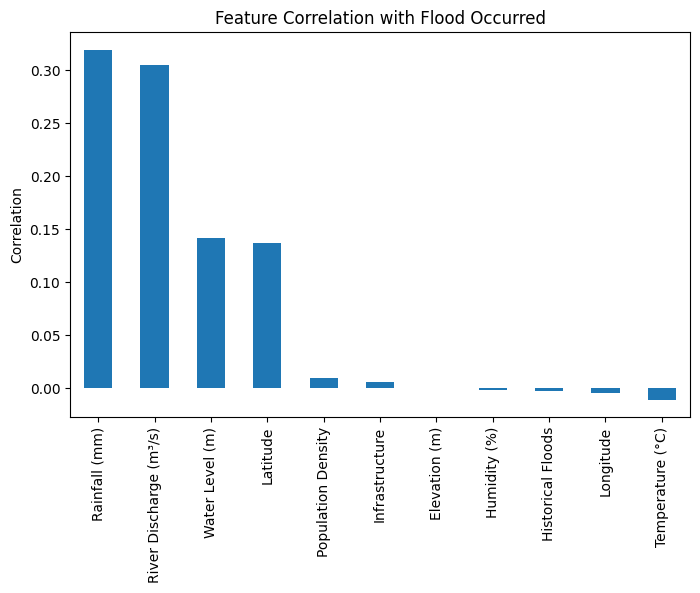

In [27]:
plt.figure(figsize=(8,5))

target_corr.drop("Flood Occurred").plot(kind="bar")

plt.ylabel("Correlation")

plt.title("Feature Correlation with Flood Occurred")

plt.show()

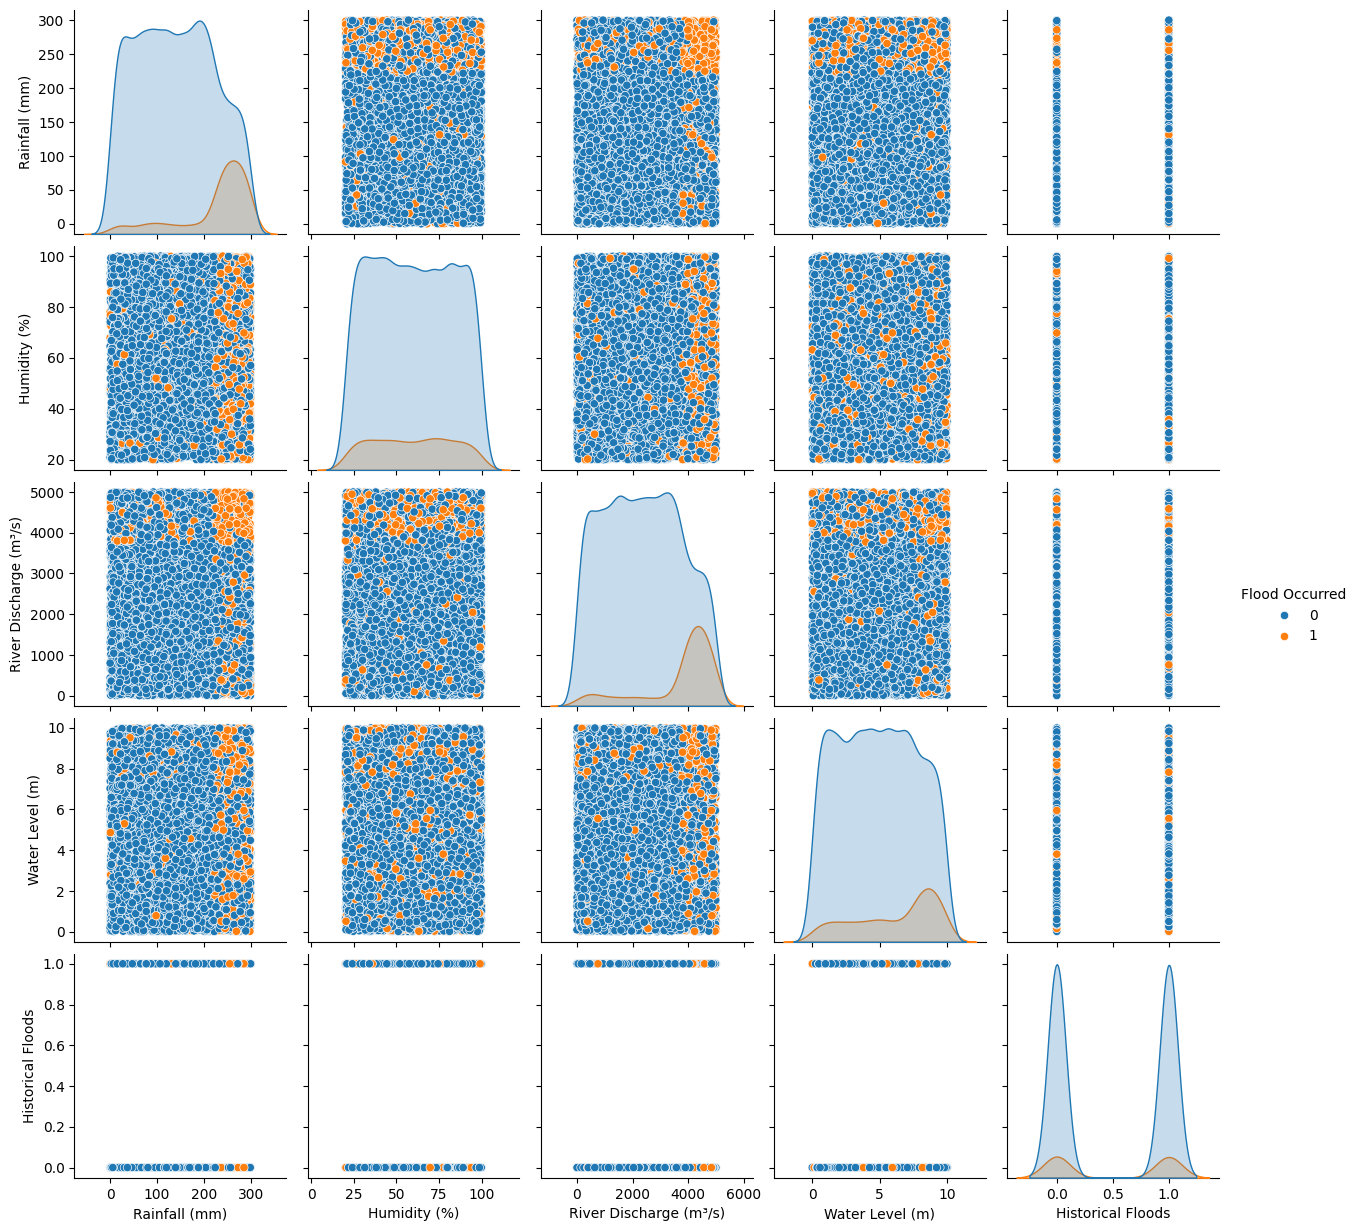

In [28]:
pair_features=[

"Rainfall (mm)",

"Humidity (%)",

"River Discharge (m³/s)",

"Water Level (m)",

"Historical Floods",

"Flood Occurred"

]

sns.pairplot(df[pair_features],hue="Flood Occurred")

plt.show()

In [29]:
import folium
from folium.plugins import MarkerCluster

print("Map Of All Places Where Floods Occured and The Precipitation is Higher Than 200 mm")
precipitation_threshold = 200

high_precipitation_data = df[(df['Rainfall (mm)'] > precipitation_threshold) & (df['Flood Occurred'] == 1)]


map_center = [high_precipitation_data['Latitude'].mean(), high_precipitation_data['Longitude'].mean()]
my_map = folium.Map(location=map_center, zoom_start=5)

marker_cluster = MarkerCluster().add_to(my_map)

for _, row in high_precipitation_data.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Rainfall: {row['Rainfall (mm)']} mm, Temp: {row['Temperature (°C)']} °C, Humidity: {row['Humidity (%)']}\% Water Level: {row['Water Level (m)']}, Elevation: {row['Elevation (m)']}"
    ).add_to(marker_cluster)

my_map

Map Of All Places Where Floods Occured and The Precipitation is Higher Than 200 mm


In [30]:
# 2. Separate Features (X) and Target (y)
# One-hot encode the categorical features from the original DataFrame `df`.
# The 'categorical_features' variable was defined in a previous cell.
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=False)

# Separate features (X) and target (y)
X = df_encoded.drop('Flood Occurred', axis=1)
y = df_encoded['Flood Occurred']

In [31]:
# 3. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
print("X_train size: {}, X_test size: {}, y_train size: {}, y_test size: {}".format(len(X_train), len(X_test), len(y_train), len(y_test)))

X_train size: 8000, X_test size: 2000, y_train size: 8000, y_test size: 2000


In [33]:
from imblearn.over_sampling import SMOTE

# 4. Handle any remaining class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [34]:
# 5. Scale the Data (Crucial for the Logistic Regression meta-model)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

### Validation Step

In [50]:
# 1. Split the resampled training data into actual training and validation sets
X_train_actual, X_val, y_train_actual, y_val = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.2, random_state=42, stratify=y_train_resampled
)

print(f"X_train_actual size: {len(X_train_actual)}, X_val size: {len(X_val)}")
print(f"y_train_actual size: {len(y_train_actual)}, y_val size: {len(y_val)}")

X_train_actual size: 11176, X_val size: 2794
y_train_actual size: 11176, y_val size: 2794


In [51]:
# 2. Scale the actual training and validation data
# Use the already fitted scaler
X_train_actual_scaled = scaler.transform(X_train_actual)
X_val_scaled = scaler.transform(X_val)

In [52]:
# 3. Initialize and Train a temporary Stacking Ensemble for validation
# We'll create a new instance to avoid interfering with the main model
stacking_ensemble_val = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model, # Re-using meta_model instance for simplicity
    cv=3 # Use fewer folds for validation training to speed it up
)

print("Training Stacking Ensemble for Validation...")
stacking_ensemble_val.fit(X_train_actual_scaled, y_train_actual)
print("Validation model training complete.")

Training Stacking Ensemble for Validation...
Validation model training complete.



=== Validation Accuracy: 99.21% ===

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1397
           1       0.99      0.99      0.99      1397

    accuracy                           0.99      2794
   macro avg       0.99      0.99      0.99      2794
weighted avg       0.99      0.99      0.99      2794



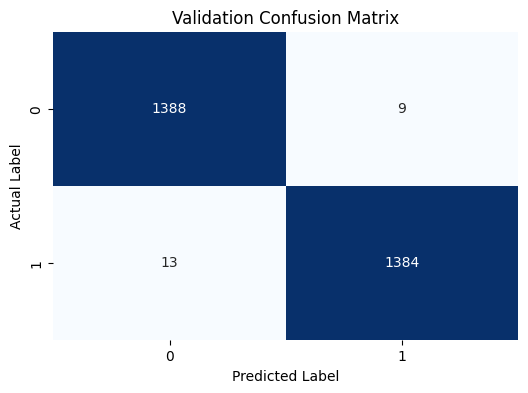

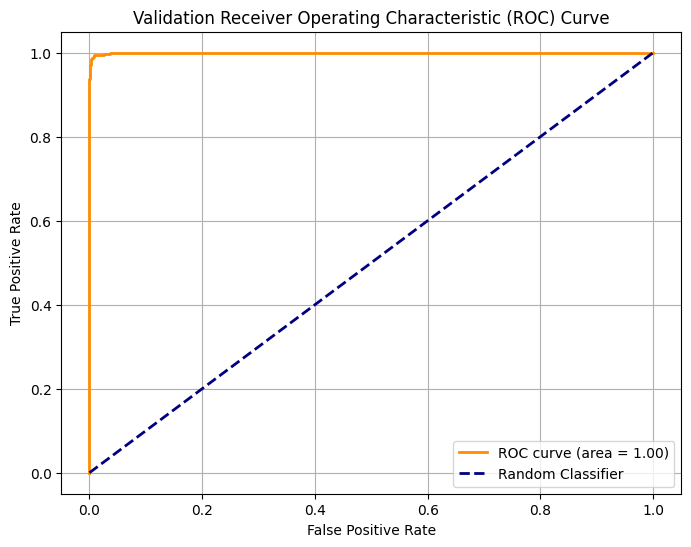

In [53]:
# 4. Evaluate the model on the Validation set
y_val_pred = stacking_ensemble_val.predict(X_val_scaled)

val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\n=== Validation Accuracy: {val_accuracy * 100:.2f}% ===")
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

val_cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

y_val_pred_proba = stacking_ensemble_val.predict_proba(X_val_scaled)[:, 1]
val_fpr, val_tpr, val_thresholds = roc_curve(y_val, y_val_pred_proba)
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(val_fpr, val_tpr, color='darkorange', lw=2, label=f'ROC curve (area = {val_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Validation Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [35]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

In [36]:
# 1. Define the Base Models (Level 0)
# We restrict depth so they don't overfit and memorize the data
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1))
]

In [37]:
# 2. Define the Meta-Model (Level 1)
# Logistic Regression is perfect here to smoothly weigh the outputs of RF and XGB
meta_model = LogisticRegression(random_state=42)

# 3. Assemble the Stacking Classifier
stacking_ensemble = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5 # Uses 5-fold cross-validation to train the meta-model safely
)

In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
# Train fit the model
stacking_ensemble.fit(X_train_scaled, y_train_resampled)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(max_depth=8, n_jobs=-1,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=True,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weight...
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.1, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=5,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=-1,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(random_state=42))

In [40]:
y_pred = stacking_ensemble.predict(X_test_scaled)

In [41]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\n=== Final Ensemble Accuracy: {accuracy * 100:.2f}% ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== Final Ensemble Accuracy: 99.60% ===

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1752
           1       0.97      1.00      0.98       248

    accuracy                           1.00      2000
   macro avg       0.99      1.00      0.99      2000
weighted avg       1.00      1.00      1.00      2000



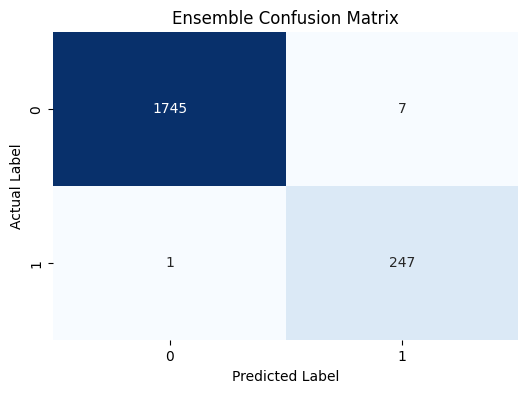

In [42]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Ensemble Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

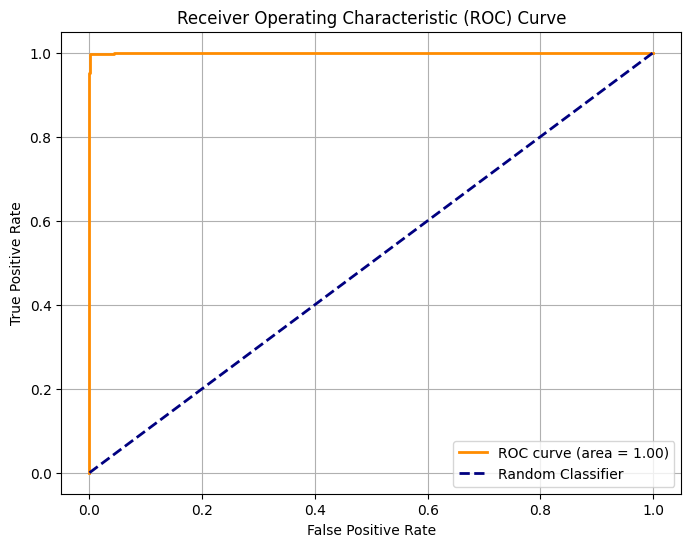

In [43]:
y_pred_proba = stacking_ensemble.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [44]:
import pickle

In [45]:
# 1. Save the trained Stacking Ensemble model
with open('flood_prediction_model.pkl', 'wb') as model_file:
    pickle.dump(stacking_ensemble, model_file)
print("Model saved successfully as 'flood_prediction_model.pkl'")

Model saved successfully as 'flood_prediction_model.pkl'


In [46]:
# 2. Save the Scaler (CRUCIAL for future predictions)
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)
print("Scaler saved successfully as 'scaler.pkl'")

Scaler saved successfully as 'scaler.pkl'


In [47]:
#Save the column names so you know exactly what order the model expects
expected_columns = list(X.columns)
with open('model_columns.pkl', 'wb') as col_file:
    pickle.dump(expected_columns, col_file)
print("Column names saved successfully as 'model_columns.pkl'")

Column names saved successfully as 'model_columns.pkl'


In [48]:
with open('flood_prediction_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

with open('model_columns.pkl', 'rb') as f:
    expected_columns = pickle.load(f)

In [49]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

# ==============================
# 3. Create Input Widgets
# ==============================
latitude = widgets.FloatText(value=18.861663, description='Latitude')
longitude = widgets.FloatText(value=78.835584, description='Longitude')

rainfall = widgets.FloatText(value=200, description='Rainfall')
temperature = widgets.FloatText(value=30, description='Temp')
humidity = widgets.FloatText(value=50, description='Humidity')

river_discharge = widgets.FloatText(value=4000, description='Discharge')
water_level = widgets.FloatText(value=7, description='Water Level')
elevation = widgets.FloatText(value=350, description='Elevation')
population_density = widgets.FloatText(value=7000, description='Population')

# Make sure these match the exact spelling in your dataset!
land_cover = widgets.Dropdown(
    options=['Water Body', 'Forest', 'Agricultural', 'Desert', 'Urban'],
    value='Urban',
    description='Land Cover'
)

soil_type = widgets.Dropdown(
    options=['Clay', 'Peat', 'Loam', 'Sandy', 'Silt'],
    value='Clay',
    description='Soil Type'
)

infrastructure = widgets.Dropdown(
    options=[0, 1],
    value=1,
    description='Infrastructure'
)

historical_floods = widgets.Dropdown(
    options=[0, 1],
    value=0,
    description='Past Floods'
)

# ==============================
# 4. Prediction Function
# ==============================
def predict_flood(b):
    with output:
        output.clear_output()   # clear old output
        try:
            # 1. Create a dictionary with ALL expected columns set to 0 initially
            input_dict = {col: 0 for col in expected_columns}

            # 2. Fill in the numerical inputs
            input_dict['Latitude'] = latitude.value
            input_dict['Longitude'] = longitude.value
            input_dict['Rainfall (mm)'] = rainfall.value
            input_dict['Temperature (°C)'] = temperature.value
            input_dict['Humidity (%)'] = humidity.value
            input_dict['River Discharge (m³/s)'] = river_discharge.value
            input_dict['Water Level (m)'] = water_level.value
            input_dict['Elevation (m)'] = elevation.value
            input_dict['Population Density'] = population_density.value
            input_dict['Infrastructure'] = infrastructure.value
            input_dict['Historical Floods'] = historical_floods.value

            # 3. Handle One-Hot Encoding for Categoricals
            # We construct the column name (e.g., 'Land Cover_Urban') and set it to 1 if it exists
            selected_land_cover = f'Land Cover_{land_cover.value}'
            if selected_land_cover in input_dict:
                input_dict[selected_land_cover] = 1

            selected_soil_type = f'Soil Type_{soil_type.value}'
            if selected_soil_type in input_dict:
                input_dict[selected_soil_type] = 1

            # 4. Convert to DataFrame and enforce strict column order
            input_df = pd.DataFrame([input_dict])
            input_df = input_df[expected_columns]

            # 5. Scale the data! (CRUCIAL)
            input_scaled = loaded_scaler.transform(input_df)

            # 6. Make the Prediction
            # predict_proba returns an array like [[prob_no_flood, prob_flood]]
            prob_flood = loaded_model.predict_proba(input_scaled)[0][1]
            prediction = loaded_model.predict(input_scaled)[0]

            # 7. Format the output nicely
            label = " HIGH RISK - FLOOD IMMINENT" if prediction == 1 else " LOW RISK - SAFE"

            print("=== Prediction Result ===")
            print(f"Risk Level: {label}")
            print(f"Confidence: {prob_flood * 100:.1f}%\n")

        except Exception as e:
            print("Error during prediction:", e)

# ==============================
# 5. UI Setup & Display
# ==============================

# Create the button
predict_button = widgets.Button(
    description='Predict Flood Risk',
    button_style='danger' # Changed to danger (red) to fit the disaster theme!
)

# Create the output area
output = widgets.Output()

# Bind the button to the function
predict_button.on_click(predict_flood)

# Display everything in a slightly cleaner layout using VBox/HBox
left_box = widgets.VBox([latitude, longitude, rainfall, temperature, humidity, river_discharge, water_level])
right_box = widgets.VBox([elevation, population_density, land_cover, soil_type, infrastructure, historical_floods])
ui_grid = widgets.HBox([left_box, right_box])

display(
    ui_grid,
    predict_button,
    output
)


Button(button_style='danger', description='Predict Flood Risk', style=ButtonStyle())

Output()